# The Curse of Dimensionality: From First Principles

> *"The curse of dimensionality is a phrase coined by Richard Bellman in 1957 when considering problems in dynamic programming and optimization."*

In machine learning, deep learning, and natural language processing, the **Curse of Dimensionality** refers to various phenomena that arise when analyzing and organizing data in high-dimensional spaces.

In this notebook, we will explore:
1. **The Discrete Curse**: Combinatorial explosion in Language Modeling ($n$-grams).
2. **The Geometric Curse in Continuous Space**:
   - **Empty Space Phenomenon** (Data sparsity).
   - **The Hypercube Corners Paradox** (Volume concentration).
   - **Distance Concentration** (Why nearest neighbors lose meaning in raw high dimensions).
3. **How Deep Learning Overcomes It**: Continuous Embeddings & The Manifold Hypothesis.
4. **Visualizations and Experiments**.
5. **Check Your Understanding Exercises**.

---
## 1. The Discrete Curse: Combinatorial Explosion in Language Models

In discrete spaces (like words or categorical variables), the number of possible configurations grows **exponentially** with the number of variables (context length $n$).

If vocabulary size is $|V|$ and context length is $n$:
$$\text{Total Possible Sequences} = |V|^n$$

Let's see this in action for small vs realistic vocabulary sizes.

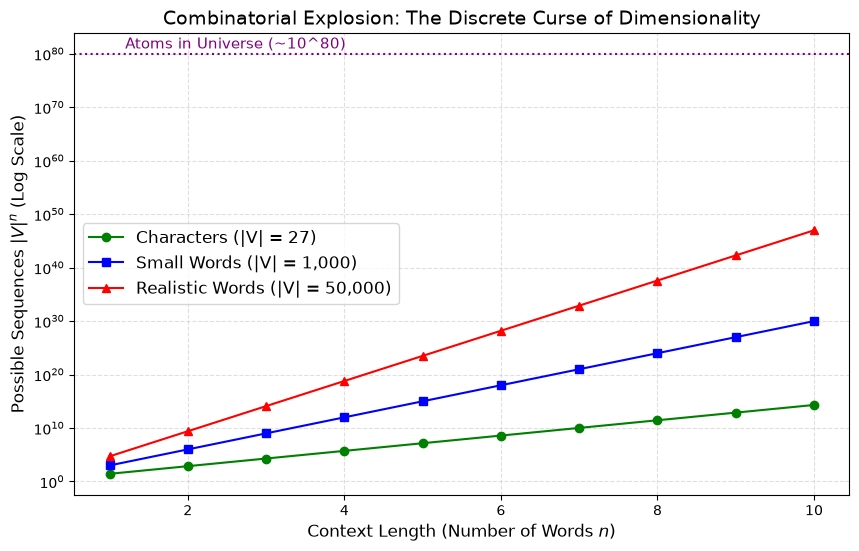

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Context lengths from 1 to 10 words
n_words = np.arange(1, 11)

# Different vocabulary sizes
v_char = 27       # Characters (a-z + .)
v_small = 1000    # Small word vocabulary
v_real = 50000    # Typical English vocabulary

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(n_words, [float(v_char)**n for n in n_words], 'g-o', label=f"Characters (|V| = {v_char})")
ax.plot(n_words, [float(v_small)**n for n in n_words], 'b-s', label=f"Small Words (|V| = {v_small:,})")
ax.plot(n_words, [float(v_real)**n for n in n_words], 'r-^', label=f"Realistic Words (|V| = {v_real:,})")

ax.set_yscale('log')
ax.set_xlabel("Context Length (Number of Words $n$)", fontsize=12)
ax.set_ylabel("Possible Sequences $|V|^n$ (Log Scale)", fontsize=12)
ax.set_title("Combinatorial Explosion: The Discrete Curse of Dimensionality", fontsize=14)
ax.grid(True, which="both", ls="--", alpha=0.4)
ax.legend(fontsize=12)

# Annotate estimated atoms in the universe (~10^80)
ax.axhline(1e80, color='purple', linestyle=':', label='Estimated Atoms in Universe (~10^80)')
ax.text(1.2, 1e81, "Atoms in Universe (~10^80)", color='purple', fontsize=11)

plt.show()

---
## 2. The Continuous Curse: Strange Geometry of High-Dimensional Space

Our human intuition is built in 2D and 3D. In 50D, 100D, or 1000D spaces, geometry behaves in bizarre and counter-intuitive ways.

### Phenomenon A: The Hypercube Corners Paradox (Where is the Volume?)

Consider a hypercube of side length $2$ centered at the origin (from $-1$ to $+1$ in each coordinate).
- **Volume of Hypercube**: $V_{\text{cube}}(d) = 2^d$.

Now place an inscribed hypersphere of radius $r = 1$ inside this cube.
- **Volume of Hypersphere**: $V_{\text{sphere}}(d) = \frac{\pi^{d/2}}{\Gamma(d/2 + 1)} r^d$.

What fraction of the cube's volume is inside the sphere as dimension $d$ grows?
$$\text{Ratio}(d) = \frac{V_{\text{sphere}}(d)}{V_{\text{cube}}(d)} \xrightarrow{d \to \infty} 0$$

**The Shocking Result**: In high dimensions, almost **100% of the volume of a hypercube lives in the outer corners**, while the center is completely empty!

<>:17: SyntaxWarning: invalid escape sequence '\i'
<>:17: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_22753/11752397.py:17: SyntaxWarning: invalid escape sequence '\i'
  plt.title("The Hypercube Corners Paradox: Sphere Volume Vanishes as $d \to \infty$", fontsize=14)


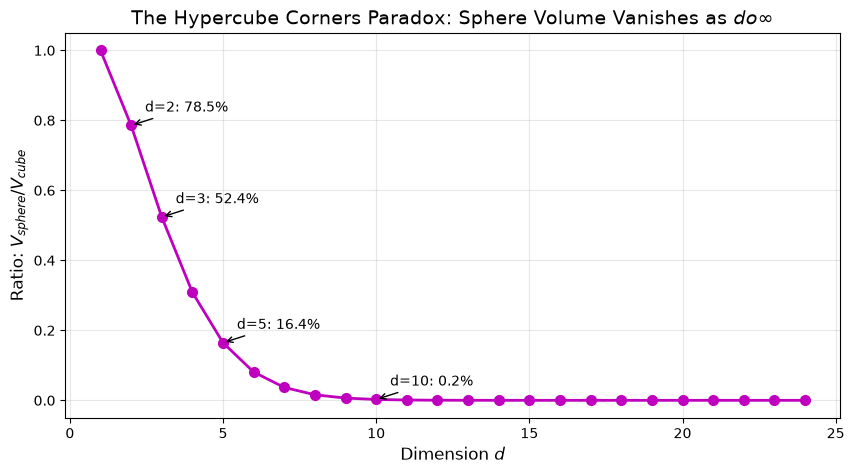

In [2]:
from scipy.special import gamma

dimensions = np.arange(1, 25)

def sphere_volume(d, r=1.0):
    return (np.pi**(d/2.0) / gamma(d/2.0 + 1.0)) * (r**d)

def cube_volume(d, side=2.0):
    return side**d

ratios = [sphere_volume(d) / cube_volume(d) for d in dimensions]

plt.figure(figsize=(10, 5))
plt.plot(dimensions, ratios, 'mo-', linewidth=2, markersize=7)
plt.xlabel("Dimension $d$", fontsize=12)
plt.ylabel("Ratio: $V_{sphere} / V_{cube}$", fontsize=12)
plt.title("The Hypercube Corners Paradox: Sphere Volume Vanishes as $d \to \infty$", fontsize=14)
plt.grid(True, alpha=0.3)

for d_point in [2, 3, 5, 10]:
    plt.annotate(f"d={d_point}: {ratios[d_point-1]*100:.1f}%", 
                 (d_point, ratios[d_point-1]),
                 textcoords="offset points", xytext=(10, 10), ha='left',
                 arrowprops=dict(arrowstyle="->", color='black'))

plt.show()

### Phenomenon B: Distance Concentration (All Points Become Equally Far)

In high dimensions, the Euclidean distance between **any two randomly chosen points** becomes virtually identical!

If $X, Y \sim \text{Uniform}(0, 1)^d$:
$$\text{dist}(X, Y) = \sqrt{\sum_{i=1}^d (X_i - Y_i)^2}$$

As $d$ increases, by the Law of Large Numbers, the sum inside the square root concentrates heavily around its expected value.

Therefore:
$$\frac{\text{dist}_{\max} - \text{dist}_{\min}}{\text{dist}_{\min}} \xrightarrow{d \to \infty} 0$$

**Meaning**: In raw high dimensions, the concept of "nearest neighbor" breaks down—everything is equally far from everything else!

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_22753/2636958818.py:20: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("Normalized Distance $D / \sqrt{d}$", fontsize=12)


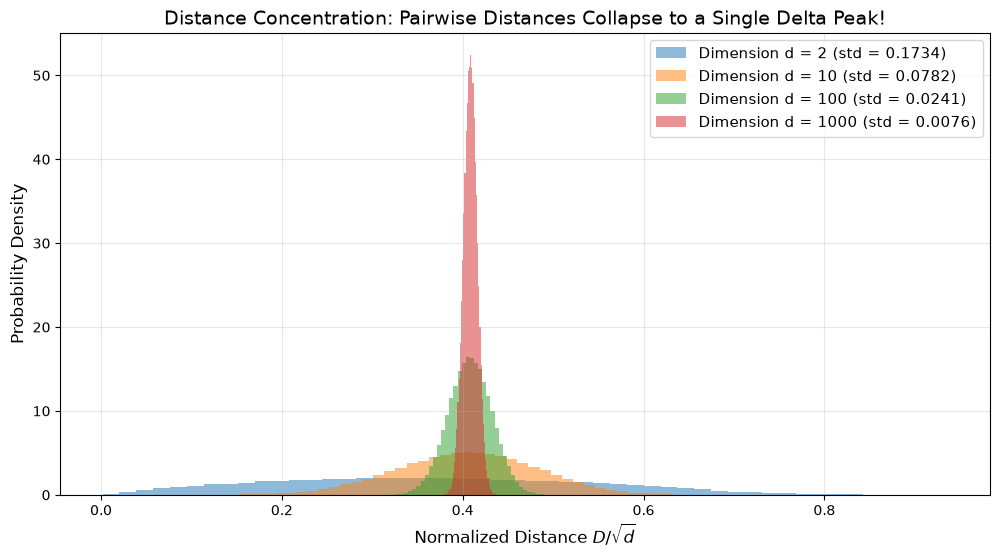

In [3]:
# Generate 500 random points in various dimensions and compute all pairwise distances
from scipy.spatial.distance import pdist

dims_to_test = [2, 10, 100, 1000]
num_samples = 500

plt.figure(figsize=(12, 6))

for d in dims_to_test:
    # Sample points uniformly in [0, 1]^d
    data = np.random.uniform(0, 1, size=(num_samples, d))
    distances = pdist(data)
    
    # Normalize distances by sqrt(d) so distributions can be compared on the same scale
    normalized_distances = distances / np.sqrt(d)
    
    plt.hist(normalized_distances, bins=50, density=True, alpha=0.5, 
             label=f"Dimension d = {d} (std = {np.std(normalized_distances):.4f})")

plt.xlabel("Normalized Distance $D / \sqrt{d}$", fontsize=12)
plt.ylabel("Probability Density", fontsize=12)
plt.title("Distance Concentration: Pairwise Distances Collapse to a Single Delta Peak!", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

---
## 3. How Deep Learning Overcomes the Curse: The Manifold Hypothesis

If high-dimensional space is so hostile, how can neural networks operate on $1{,}000$-dimensional embeddings or $1{,}000{,}000$-pixel images?

### The Manifold Hypothesis:
> *Real-world data (like language, natural images, or audio) does NOT fill the entire high-dimensional space uniformly. Instead, meaningful data concentrates on a **much lower-dimensional, smooth sub-manifold** embedded inside the high-dimensional space.*

```
      High-Dimensional Space R^D (e.g. D = 10,000 words or pixels)
      ┌──────────────────────────────────────────────────────────┐
      │                                                          │
      │      Empty Void (Noise / Random Combinations)            │
      │                                                          │
      │             ~~~~~~~~ Lower-Dimensional ~~~~~~~~          │
      │             ~~~~~~ Smooth Data Manifold ~~~~~~~          │
      │             (cat, dog, walk, run, natural text)          │
      │                                                          │
      └──────────────────────────────────────────────────────────┘
```

### Bengio's Continuous Word Embeddings:
1. **Embedding Matrix $C$**: Compresses the discrete $|V| = 100{,}000$ space into a smooth $m = 30$ dimensional continuous manifold.
2. **Smooth Neural Network**: Because neural networks are smooth differentiable functions, learning $f(\text{embedding}(\text{"cat"}))$ automatically generalizes to nearby points on the manifold $f(\text{embedding}(\text{"dog"}))$.
3. **Curse Conquered**: Instead of needing $10^{50}$ training sentences to cover all discrete combos, a few million sentences learn the shape of the manifold!

---
## 4. Check Your Understanding: Exercises

Test your understanding by completing the functions and running the test cells below!

### Exercise 1: Combinatorial Sequence Count
Write a function `num_combinations(vocab_size, context_length)` that returns the total possible sequence combinations $|V|^n$ as a float.

In [1]:
def num_combinations(vocab_size: int, context_length: int) -> float:
    return vocab_size**context_length

In [2]:
# === Test Suite for Exercise 1 ===
test_cases = [
    ((27, 3), 27**3),
    ((1000, 4), 1000**4),
    ((100000, 2), 100000**2)
]

for (v, n), expected in test_cases:
    yours = num_combinations(v, n)
    ok = 'OK' if yours is not None and abs(yours - expected) < 1e-5 else 'WRONG!'
    print(f"{ok} for vocab={v}, context={n}: expected {expected}, yours returned {yours}")

OK for vocab=27, context=3: expected 19683, yours returned 19683
OK for vocab=1000, context=4: expected 1000000000000, yours returned 1000000000000
OK for vocab=100000, context=2: expected 10000000000, yours returned 10000000000


### Exercise 2: Distance Ratio in High Dimensions
Write a function `distance_contrast_ratio(d: int, num_points: int = 100) -> float` that:
1. Generates `num_points` uniformly at random in $[0, 1]^d$.
2. Computes all pairwise Euclidean distances.
3. Computes and returns the ratio:
$$\text{Contrast Ratio} = \frac{\text{dist}_{\max} - \text{dist}_{\min}}{\text{dist}_{\min}}$$

*(Notice how this ratio drops toward 0 as $d$ increases, proving that distance contrast vanishes in high dimensions!)*

In [22]:
from scipy.spatial.distance import pdist
import numpy as np

def distance_contrast_ratio(d: int, num_points: int = 100) -> float:
    # TODO: generate uniform points in [0, 1]^d
    # TODO: compute pairwise distances with pdist(points)
    # TODO: return (max_dist - min_dist) / min_dist
    uni_points = np.random.uniform(0, 1, size=(num_points, d))
    pair_distances = pdist(uni_points)
    return (max(pair_distances) - min(pair_distances)) / min(pair_distances)

In [23]:
# === Test Suite for Exercise 2 ===
# Contrast ratio in 2D is large (> 1.5), while in 1000D it collapses (< 0.2)
ratio_2d = distance_contrast_ratio(2, 200)
ratio_1000d = distance_contrast_ratio(1000, 200)

ok_2d = 'OK' if ratio_2d is not None and ratio_2d > 1.0 else 'WRONG!'
print(f"{ok_2d} for 2D contrast ratio: expected > 1.0, yours returned {ratio_2d}")

ok_1000d = 'OK' if ratio_1000d is not None and ratio_1000d < 0.25 else 'WRONG!'
print(f"{ok_1000d} for 1000D contrast ratio: expected < 0.25 (contrast collapses), yours returned {ratio_1000d}")

OK for 2D contrast ratio: expected > 1.0, yours returned 787.4604447710996
OK for 1000D contrast ratio: expected < 0.25 (contrast collapses), yours returned 0.1700335949050485
